# Kerr lensing dataset (GPU)

Generates the training data for the FNO light-bending operator and the inverse
problem. For a grid of black holes (spin `a`, inclination) on a fixed image grid,
the GPU ray tracer records how each hole bends light: where every pixel's ray
lands on the disk, the redshift there, and where escaping rays point on the sky.
Those fields are the lensing operator.

Each black hole is traced once. To get an observed image you push any disk
emission field through the stored `(hit_r, hit_phi)` (see `emission_to_image`), so
one trace gives unlimited `(emission -> image)` pairs: emission is free data
augmentation for the FNO, and the inverse problem maps images (or the fields) back
to `a` and inclination.

Turn on the GPU (Settings -> Accelerator -> GPU T4), then Run All. The output
lands in `/kaggle/working/kerr_lensing/`; use **Save Version** and publish that
output as a Kaggle Dataset to attach to your FNO / inverse / PINN notebooks.


In [1]:
import os
import sys
import time
import torch

# The helper modules are written to /tmp/bhml, not /kaggle/working, so the notebook
# output (and any dataset made from it) is just kerr_lensing/.
os.makedirs("/tmp/bhml", exist_ok=True)
sys.path.insert(0, "/tmp/bhml")
torch.set_default_dtype(torch.float32)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "|",
      torch.cuda.get_device_name(0) if device == "cuda" else "CPU (enable the GPU)")


device: cuda | Tesla T4


## The ray tracer

The same engine as `simulation/viz/gpu_render.py`, written to `/tmp/bhml` and imported.

In [2]:
%%writefile /tmp/bhml/gpu_render.py
"""Vectorized Kerr ray tracer in PyTorch, for GPU rendering of flythrough frames.

This is a tensor port of the C++ engine: the Kerr inverse-metric terms (generated
by matlab/derive_kerr.m), the Hamiltonian right-hand side, and a backward ray
tracer, all rewritten so that every pixel of a frame is one row of a big state
tensor and a single GPU steps them together. The physics matches simulation/:
the same null geodesics, the same disk with its g^4 Doppler + gravitational
shading, plus a gravitationally lensed starfield behind the hole.
"""

import math
import warnings

import torch

# State columns, matching the C++ KerrIndex enum.
KT, KR, KTH, KPHI, KPT, KPR, KPTH, KPPH = range(8)


def kerr_terms(r, th, a, M):
    """Inverse-metric components and their r, theta derivatives, elementwise.

    A transcription of include/kerr_generated.hpp, with torch ops in place of
    std::sin/cos/pow so they run on whole tensors at once. The expressions are the
    generated ones, regrouped so shared pieces (sin/cos, 1/Sigma, 1/Delta, powers
    of r) are computed once: in eager mode every distinct op is a separate GPU
    kernel launch, so this alone roughly halves the kernels per RHS evaluation.
    Returns a dict of the 15 fields the RHS needs.
    """
    s = torch.sin(th)
    c = torch.cos(th)
    s2 = s * s
    c2 = c * c
    cs = c * s
    c2th = c2 - s2                           # cos(2 th)
    # On the spin axis (theta = 0 or pi) Boyer-Lindquist coordinates are singular:
    # the terms below carry 1/sin^2 and 1/sin^3. We keep this barrier HONEST (only a
    # tiny floor to avoid a literal divide-by-zero), because it is exactly the force
    # that turns a near-axis ray around; flooring it harder stops the turnaround and
    # lets the ray punch through the pole. The turnaround is instead resolved by
    # shrinking the step near the axis (see trace_step), and any ray that still
    # crosses the axis is reflected there.
    sin_safe = torch.clamp(s.abs(), min=1e-5)
    inv_s2 = 1.0 / (sin_safe * sin_safe)

    a2 = a * a
    a4 = a2 * a2
    r2 = r * r
    r3 = r2 * r
    r4 = r2 * r2
    Sig = a2 * c2 + r2                       # Sigma = r^2 + a^2 cos^2 th
    Del = r2 - 2.0 * M * r + a2              # Delta = r^2 - 2Mr + a^2
    a2r2 = a2 + r2
    iSig = 1.0 / Sig
    iDel = 1.0 / Del
    iSig2 = iSig * iSig
    iSD = iSig * iDel
    dDel = 2.0 * r - 2.0 * M                 # d Delta / dr
    A = a2r2 * a2r2 - a2 * s2 * Del

    k = {}
    k["gtt"] = -A * iSD
    k["d_r_gtt"] = (-(4.0 * r * a2r2 - a2 * s2 * dDel) * iSD
                    + 2.0 * r * A * iSig2 * iDel
                    + A * dDel * iDel * iSD)
    k["d_th_gtt"] = 2.0 * a2 * cs * iSig * (1.0 - A * iSD)
    k["gtph"] = -2.0 * M * a * r * iSD
    k["d_r_gtph"] = (2.0 * M * a * iSig2 * iDel * iDel
                     * (-a4 * c2 - 4.0 * M * r3 + 3.0 * r4 + a2 * r2 * (1.0 + c2)))
    k["d_th_gtph"] = -4.0 * M * a2 * a * r * cs * iSig2 * iDel
    k["gphph"] = -inv_s2 * (2.0 * M * r + a2 * s2 - a2 - r2) * iSD
    k["d_r_gphph"] = (
        -2.0 * inv_s2 * iSig2 * iDel * iDel
        * (
            -4.0 * M * r4 + a4 * r + r4 * r + 4.0 * M * M * r3
            + 2.0 * a2 * r3 * (1.0 - s2) - 4.0 * M * a2 * r2
            - a4 * r * s2 * (1.0 + c2) + 3.0 * M * a2 * r2 * s2
            + M * a4 * c2 * s2
        )
    )
    k["d_th_gphph"] = (
        -2.0 * c * inv_s2 / sin_safe * iSig2 * iDel
        * (
            0.5 * a4 * c2th - 2.0 * M * r3 + 0.25 * a4 * c2th * c2th + 0.25 * a4
            + r4 + a2 * r2 * (1.0 + c2th) - 2.0 * M * a2 * r * c2th
        )
    )
    k["grr"] = Del * iSig
    k["d_r_grr"] = 2.0 * iSig2 * (M * r2 - a2 * r - M * a2 * c2 + a2 * r * c2)
    k["d_th_grr"] = 2.0 * a2 * cs * iSig2 * Del
    k["gthth"] = iSig
    k["d_r_gthth"] = -2.0 * r * iSig2
    k["d_th_gthth"] = 2.0 * a2 * cs * iSig2
    return k


def kerr_rhs(Y, a, M):
    """dY/dlambda for a batch of Kerr geodesics; mirrors kerr_rhs in kerr.cpp."""
    r, th = Y[:, KR], Y[:, KTH]
    pt, pr, pth, pph = Y[:, KPT], Y[:, KPR], Y[:, KPTH], Y[:, KPPH]
    k = kerr_terms(r, th, a, M)

    # Momentum products shared by both force terms.
    ptpt, ptpph, pphpph = pt * pt, 2.0 * pt * pph, pph * pph
    prpr, pthpth = pr * pr, pth * pth

    def quad(a_tt, a_tph, a_phph, a_rr, a_thth):
        return (a_tt * ptpt + a_tph * ptpph + a_phph * pphpph
                + a_rr * prpr + a_thth * pthpth)

    zero = torch.zeros_like(r)               # dp_t = dp_phi = 0 (conserved)
    return torch.stack([
        k["gtt"] * pt + k["gtph"] * pph,
        k["grr"] * pr,
        k["gthth"] * pth,
        k["gtph"] * pt + k["gphph"] * pph,
        zero,
        -0.5 * quad(k["d_r_gtt"], k["d_r_gtph"], k["d_r_gphph"],
                    k["d_r_grr"], k["d_r_gthth"]),
        -0.5 * quad(k["d_th_gtt"], k["d_th_gtph"], k["d_th_gphph"],
                    k["d_th_grr"], k["d_th_gthth"]),
        zero,
    ], dim=1)


def rk4(Y, h, a, M):
    """One classical RK4 step with a per-ray step size h (shape [P, 1])."""
    k1 = kerr_rhs(Y, a, M)
    k2 = kerr_rhs(Y + 0.5 * h * k1, a, M)
    k3 = kerr_rhs(Y + 0.5 * h * k2, a, M)
    k4 = kerr_rhs(Y + h * k3, a, M)
    return Y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


# --- disk physics, camera, starfield ---------------------------------------- #

def isco_radius(a, M=1.0):
    """Prograde innermost stable circular orbit (Bardeen, Press & Teukolsky 1972).
    The disk's inner edge: inside it gas can no longer orbit and plunges in."""
    a = a / M
    z1 = 1 + (1 - a * a) ** (1 / 3) * ((1 + a) ** (1 / 3) + (1 - a) ** (1 / 3))
    z2 = math.sqrt(3 * a * a + z1 * z1)
    return M * (3 + z2 - math.sqrt((3 - z1) * (3 + z1 + 2 * z2)))


def disk_redshift(r, p_t, p_ph, a, M=1.0):
    """g = nu_obs / nu_emit for the orbiting disk gas; mirrors disk_redshift()
    in raytrace.cpp. Returns 0 inside the circular photon orbit (3M at a=0), where
    the root turns negative; that is well inside the ISCO, so the disk never hits it."""
    sM = math.sqrt(M)
    r32 = r ** 1.5
    denom = r ** 3 - 3.0 * M * r * r + 2.0 * a * sM * r32
    omega = sM / (r32 + a * sM)
    ut = (r32 + a * sM) / torch.sqrt(torch.clamp(denom, min=1e-9))
    nu_emit = -ut * (p_t + omega * p_ph)
    g = torch.where((denom > 0) & (nu_emit > 0), (-p_t) / nu_emit, torch.zeros_like(r))
    return g


def camera_rays(cam, device):
    """Build the initial Kerr state for every pixel of a perspective camera.

    cam: dict with a, incl (rad), az (rad), dist, fov (rad), res (H, W),
         r_in, r_out. Returns the state tensor Y [P, 8] (P = H*W).
    """
    H, W = cam["res"]
    D, incl, az = cam["dist"], cam["incl"], cam["az"]
    # Camera position and an orthonormal frame looking at the origin.
    C = torch.tensor([D * math.sin(incl) * math.cos(az),
                      D * math.sin(incl) * math.sin(az),
                      D * math.cos(incl)], device=device)
    f = -C / C.norm()
    up_w = torch.tensor([0.0, 0.0, 1.0], device=device)
    right = torch.cross(f, up_w, dim=0)
    right = right / right.norm()
    up = torch.cross(right, f, dim=0)

    tanh = math.tan(0.5 * cam["fov"])
    aspect = W / H
    ys = torch.linspace(1.0, -1.0, H, device=device) * tanh          # top to bottom
    xs = torch.linspace(-1.0, 1.0, W, device=device) * tanh * aspect
    gx, gy = torch.meshgrid(xs, ys, indexing="xy")                   # [H, W]
    d = (f[None, None, :] + gx[..., None] * right[None, None, :]
         + gy[..., None] * up[None, None, :])
    d = d / d.norm(dim=-1, keepdim=True)
    d = d.reshape(-1, 3)                                             # [P, 3]

    r = C.norm()
    th = torch.acos(C[2] / r)
    ph = torch.atan2(C[1], C[0])
    sth, cth, sph, cph = math.sin(th), math.cos(th), math.sin(ph), math.cos(ph)
    rhat = torch.tensor([sth * cph, sth * sph, cth], device=device)
    thhat = torch.tensor([cth * cph, cth * sph, -sth], device=device)
    phhat = torch.tensor([-sph, cph, 0.0], device=device)

    drdl = d @ rhat
    r_dth = d @ thhat
    rs_dph = d @ phhat

    P = d.shape[0]
    Y = torch.zeros(P, 8, device=device)
    Y[:, KR] = r
    Y[:, KTH] = th
    Y[:, KPHI] = ph
    Y[:, KPT] = -1.0
    Y[:, KPR] = drdl
    Y[:, KPTH] = r * r_dth
    Y[:, KPPH] = r * sth * rs_dph
    return Y


def make_starfield(n_stars=90000, th_res=2048, ph_res=4096, seed=7, device="cpu"):
    """A fixed lat-long sky of stars, sampled later by ray direction.

    Each star is splatted a little wider than a texel so it survives bilinear
    lookup and smears into an arc when the hole lenses that part of the sky.
    Stars are spread uniformly over the sphere (not in theta), so the poles are
    not crowded.
    """
    g = torch.Generator(device="cpu").manual_seed(seed)
    sky = torch.zeros(th_res, ph_res)
    th = torch.acos(1 - 2 * torch.rand(n_stars, generator=g))
    ti = (th / math.pi * (th_res - 1)).long().clamp(1, th_res - 2)
    pj = torch.randint(0, ph_res, (n_stars,), generator=g)
    mag = 0.25 + 0.75 * torch.rand(n_stars, generator=g) ** 4        # mostly faint, few bright
    for dv, du, w in [(0, 0, 1.0), (1, 0, 0.3), (-1, 0, 0.3), (0, 1, 0.3), (0, -1, 0.3)]:
        vi = (ti + dv).clamp(0, th_res - 1)
        ui = (pj + du) % ph_res
        sky.index_put_((vi, ui), mag * w, accumulate=True)
    return sky.clamp(0, 1).to(device)


def sample_starfield(sky, th, ph):
    """Bilinearly sample the sky at ray directions, wrapping in phi."""
    th_res, ph_res = sky.shape
    ph = torch.nan_to_num(ph, nan=0.0, posinf=0.0, neginf=0.0)
    th = torch.nan_to_num(th, nan=0.0, posinf=0.0, neginf=0.0)
    u = ((ph / (2 * math.pi)) % 1.0) * ph_res
    v = torch.clamp(th / math.pi, 0, 1) * (th_res - 1)
    u0 = torch.floor(u).long() % ph_res
    u1 = (u0 + 1) % ph_res
    v0 = torch.clamp(torch.floor(v).long(), 0, th_res - 1)
    v1 = torch.clamp(v0 + 1, 0, th_res - 1)
    fu = u - torch.floor(u)
    fv = v - v0.float()
    return (sky[v0, u0] * (1 - fu) * (1 - fv) + sky[v0, u1] * fu * (1 - fv)
            + sky[v1, u0] * (1 - fu) * fv + sky[v1, u1] * fu * fv)


# --- tracing ----------------------------------------------------------------- #

def trace_step(Y, active, otype, hit_r, hit_ph, hit_g, sky_th, sky_ph, r_esc,
               a, M, C0, r_cap, r_in, r_out):
    """Advance every ray by one RK4 step and record any that finished.

    This is the whole per-step body (step size, RK4, pole reflection, horizon /
    disk / sky tests), written purely functionally so torch.compile can fuse it
    into a handful of GPU kernels instead of ~500 separate eager launches.
    r_esc is a 0-d tensor (it changes with the camera distance, and a Python
    float would force a recompile); the other scalars are fixed for a whole clip.

    For a ray that hits the disk we keep where it hit (r, phi) and its redshift g,
    so the disk can be re-shaded for any moment of its rotation without tracing
    again. For a ray that escapes we keep its asymptotic direction on the sky.
    """
    PI = math.pi
    r_before = Y[:, KR]
    th_before = Y[:, KTH]
    ph_before = Y[:, KPHI]
    # Step size scales with radius (big far away, small near the hole) and
    # shrinks toward the spin axis in proportion to sin(theta), where the theta
    # motion turns around very sharply for near-axis rays. Without this the
    # turnaround is overshot and those rays scatter into a vertical streak.
    sin_now = torch.sin(th_before).abs().clamp(min=0.04)
    h = torch.clamp(C0 * r_before * sin_now, max=0.6)
    # Near the horizon Delta -> 0 and the inverse metric's 1/Delta terms blow up. A
    # step sized only by r lets the last step into the hole put its RK4 stages at or
    # past the horizon, and those rays come back NaN or get flung out to the disk or
    # sky (stray dots inside the shadow). So also cap the step to move a ray at most
    # a tenth of its remaining distance to r_+ at its current radial speed.
    a_t = torch.as_tensor(a, dtype=Y.dtype, device=Y.device)
    r_plus = M + torch.sqrt(torch.clamp(M * M - a_t * a_t, min=0.0))
    delta = r_before * r_before - 2.0 * M * r_before + a_t * a_t
    sigma = r_before * r_before + a_t * a_t * torch.cos(th_before) ** 2
    r_dot = delta / sigma * Y[:, KPR]
    h = torch.minimum(h, 0.1 * torch.clamp(r_before - r_plus, min=0.0) / (r_dot.abs() + 1e-12))
    Yn = torch.where(active[:, None], rk4(Y, h[:, None], a, M), Y)
    # Anything still non-finite can only come from those singular terms: count it as
    # captured, rather than leaving it "in flight" (and active) for the whole trace.
    blown = active & ~torch.isfinite(Yn).all(dim=1)

    # Pole crossing: if a ray steps past the spin axis (theta out of [0, pi]),
    # reflect it back and advance phi by pi. This is the exact continuation of a
    # geodesic through the axis, and keeps BL coordinates well defined.
    th = Yn[:, KTH]
    flip = active & ((th < 0.0) | (th > PI))
    th_ref = torch.where(th < 0.0, -th, torch.where(th > PI, 2.0 * PI - th, th))
    th = torch.where(flip, th_ref, th)
    ph = torch.where(flip, Yn[:, KPHI] + PI, Yn[:, KPHI])
    pth = torch.where(flip, -Yn[:, KPTH], Yn[:, KPTH])
    r_now = Yn[:, KR]
    Y = torch.stack([Yn[:, KT], r_now, th, ph, Yn[:, KPT], Yn[:, KPR], pth,
                     Yn[:, KPPH]], dim=1)

    # horizon
    hit_h = active & ((r_now <= r_cap) | blown)
    otype = otype.masked_fill(hit_h, 1)
    active = active & ~hit_h
    # equatorial crossing into the disk annulus (computed for all rays, masked)
    f0 = th_before - PI / 2.0
    f1 = th - PI / 2.0
    frac = f0 / (f0 - f1)
    r_cross = r_before + frac * (r_now - r_before)
    ph_cross = ph_before + frac * (ph - ph_before)
    on_disk = active & (f0 * f1 < 0) & (r_cross >= r_in) & (r_cross <= r_out)
    g = disk_redshift(r_cross, Y[:, KPT], Y[:, KPPH], a, M)
    hit_r = torch.where(on_disk, r_cross, hit_r)
    hit_ph = torch.where(on_disk, ph_cross, hit_ph)
    hit_g = torch.where(on_disk, g, hit_g)
    otype = otype.masked_fill(on_disk, 2)
    active = active & ~on_disk
    # Escape to the sky. Far from the hole space is nearly flat, so the ray's
    # direction of travel is (dr, r dth, r sin th dph) in the local spherical
    # frame; turned into Cartesian, that is where on the celestial sphere it looks.
    esc = active & (r_now > r_esc) & (Y[:, KPR] > 0)
    st, ct, sp, cp = torch.sin(th), torch.cos(th), torch.sin(ph), torch.cos(ph)
    st_safe = st.abs().clamp(min=1e-5)
    v_r = Y[:, KPR]
    v_th = pth / r_now
    v_ph = Yn[:, KPPH] / (r_now * st_safe)
    vx = v_r * st * cp + v_th * ct * cp - v_ph * sp
    vy = v_r * st * sp + v_th * ct * sp + v_ph * cp
    vz = v_r * ct - v_th * st
    vn = torch.sqrt(vx * vx + vy * vy + vz * vz).clamp(min=1e-12)
    sky_th = torch.where(esc, torch.acos((vz / vn).clamp(-1.0, 1.0)), sky_th)
    sky_ph = torch.where(esc, torch.atan2(vy, vx), sky_ph)
    otype = otype.masked_fill(esc, 3)
    active = active & ~esc
    return Y, active, otype, hit_r, hit_ph, hit_g, sky_th, sky_ph


# torch.compile of trace_step, built lazily on first use. If compilation is not
# available (old torch, no compiler toolchain, unsupported GPU) or fails at run
# time, we fall back to the eager function once, with a warning, and stay there.
_STEP = {"fn": None, "compiled": False}


def get_step_fn(use_compile=True):
    if not use_compile:
        return trace_step
    if _STEP["fn"] is None:
        _STEP["fn"], _STEP["compiled"] = trace_step, False
        if hasattr(torch, "compile"):
            try:
                # dynamic=True: the ray count shrinks as rays are compacted, and
                # we do not want a recompile for every new batch size.
                _STEP["fn"] = torch.compile(trace_step, dynamic=True)
                _STEP["compiled"] = True
            except Exception as e:  # pragma: no cover - depends on the platform
                warnings.warn(f"torch.compile unavailable ({e!r}); using eager mode")
    if not _STEP["compiled"]:
        return trace_step

    def safe_step(*args):
        try:
            return _STEP["fn"](*args)
        except Exception as e:  # pragma: no cover - depends on the platform
            warnings.warn(f"compiled step failed ({e!r}); falling back to eager mode")
            _STEP["fn"], _STEP["compiled"] = trace_step, False
            return trace_step(*args)
    return safe_step


def trace_frame(cam, a, device, n_steps=6000, C0=0.013, use_compile=True,
                check_every=32, compact_below=0.85):
    """Trace one ray per pixel and return what each ray hit (a dict of [P] tensors).

    otype: 0 never finished, 1 horizon, 2 disk, 3 sky. For disk rays hit_r,
    hit_ph, hit_g give where the disk was hit and the redshift there; for sky rays
    sky_th, sky_ph give the direction on the celestial sphere. Nothing here depends
    on time, so a fixed camera needs this only once for a whole clip.

    use_compile fuses each integration step with torch.compile (falls back to
    eager automatically). Every check_every steps we sync once with the GPU to
    count the rays still in flight; if fewer than compact_below of the current
    batch remain, the finished rays are dropped from the batch, so later steps
    only pay for rays that are still flying.

    n_steps is only a cap: the trace stops once all but a handful of rays have
    finished, so most frames never reach it. Rays that leave close to the spin
    axis take the longest (their steps shrink with sin(theta)), up to a few
    thousand steps in near face-on views; a lower cap leaves them unfinished.
    """
    M = 1.0
    a = float(a)
    # a, r_cap, r_in and r_out are passed to the compiled step as 0-d tensors, for
    # the same reason r_esc is: a Python float is baked into the compiled graph as a
    # constant, so a NEW value forces a fresh torch.compile. They are constant across
    # a single clip (fine as floats there), but a dataset sweeps a different hole
    # every call, which would recompile on every one and never finish. As tensors the
    # step compiles once and is reused for every hole.
    r_cap = torch.tensor(1.01 * (M + math.sqrt(max(M * M - a * a, 0.0))), device=device)
    r_in = torch.tensor(float(cam["r_in"]), device=device)
    r_out = torch.tensor(float(cam["r_out"]), device=device)
    r_esc = torch.tensor(cam["dist"] * 1.4, device=device)
    a = torch.tensor(a, device=device)
    C0 = float(C0)
    step = get_step_fn(use_compile)

    Y = camera_rays(cam, device)
    P = Y.shape[0]
    names = ("otype", "hit_r", "hit_ph", "hit_g", "sky_th", "sky_ph")
    # Per-pixel results for the whole frame; the working batch is written back
    # into these whenever it is compacted, and once at the end.
    out = dict(otype=torch.zeros(P, dtype=torch.int8, device=device),
               hit_r=torch.zeros(P, device=device), hit_ph=torch.zeros(P, device=device),
               hit_g=torch.zeros(P, device=device), sky_th=torch.zeros(P, device=device),
               sky_ph=torch.zeros(P, device=device))
    work = [out[n].clone() for n in names]
    active = torch.ones(P, dtype=torch.bool, device=device)
    idx = None                       # pixel index of each working ray (None = all)

    def write_back():
        for n, w in zip(names, work):
            if idx is None:
                out[n].copy_(w)
            else:
                out[n][idx] = w

    # Inside a step there is no GPU-to-CPU synchronisation at all; we only sync
    # every check_every steps to decide on compaction / early exit.
    for i in range(n_steps):
        if i > 0 and i % check_every == 0:
            n_active = int(active.sum())
            if n_active <= max(1, P // 2000):
                break  # only a few near-critical stragglers left; call them dark
            if n_active < compact_below * active.shape[0]:
                write_back()
                keep = active.nonzero().squeeze(1)
                idx = keep if idx is None else idx[keep]
                Y, active = Y[keep], active[keep]
                work = [w[keep] for w in work]
        Y, active, *work = step(Y, active, *work, r_esc, a, M, C0, r_cap, r_in, r_out)
    write_back()
    out["res"] = cam["res"]
    out["r_in"], out["r_out"], out["a"] = r_in, r_out, a
    return out


# --- shading ----------------------------------------------------------------- #

def fire_lut(device, n=256):
    """Black -> ember red -> orange -> gold -> white-hot: a hot-gas palette."""
    stops = torch.tensor([0.0, 0.12, 0.32, 0.55, 0.78, 1.0])
    cols = torch.tensor([[0.00, 0.00, 0.00],
                         [0.28, 0.03, 0.00],
                         [0.78, 0.20, 0.02],
                         [1.00, 0.52, 0.10],
                         [1.00, 0.82, 0.45],
                         [1.00, 0.98, 0.92]])
    x = torch.linspace(0, 1, n)
    j = torch.clamp(torch.searchsorted(stops, x, right=True) - 1, 0, len(stops) - 2)
    w = ((x - stops[j]) / (stops[j + 1] - stops[j]))[:, None]
    return (cols[j] * (1 - w) + cols[j + 1] * w).to(device)


def disk_omega(r, a, M=1.0):
    """Keplerian angular velocity of prograde circular orbits in Kerr."""
    return math.sqrt(M) / (r ** 1.5 + a * math.sqrt(M))


class DiskTexture:
    """Turbulent, streaky gas pattern on the disk, as a sum of random waves in
    (phi, log r). Waves are integer in phi so the pattern wraps around, and are
    mostly tight in radius and loose in phi, so they read as orbiting streaks."""

    def __init__(self, n_waves=40, seed=3, contrast=0.9, device="cpu"):
        g = torch.Generator(device="cpu").manual_seed(seed)
        self.m = torch.randint(1, 14, (n_waves,), generator=g).float().to(device)
        self.k = (6 + 40 * torch.rand(n_waves, generator=g)).to(device)
        self.phase = (2 * math.pi * torch.rand(n_waves, generator=g)).to(device)
        amp = 1.0 / torch.sqrt(self.k.cpu() / 6.0 + self.m.cpu() / 3.0)
        self.amp = (amp / amp.square().sum().sqrt()).to(device)
        self.contrast = contrast

    def __call__(self, r, ph):
        u = torch.log(r)
        arg = ph[:, None] * self.m + u[:, None] * self.k + self.phase
        n = (torch.cos(arg) * self.amp).sum(-1)          # ~unit variance noise
        return torch.exp(self.contrast * n - 0.5 * self.contrast ** 2)  # mean ~1


def _gauss_blur(img, sigma):
    """Separable Gaussian blur of an [H, W, C] image."""
    import torch.nn.functional as F
    rad = max(1, int(3 * sigma))
    x = torch.arange(-rad, rad + 1, device=img.device, dtype=img.dtype)
    k = torch.exp(-0.5 * (x / sigma) ** 2)
    k = k / k.sum()
    t = img.permute(2, 0, 1)[:, None]                    # [C, 1, H, W]
    t = F.conv2d(F.pad(t, (rad, rad, 0, 0), mode="replicate"), k.view(1, 1, 1, -1))
    t = F.conv2d(F.pad(t, (0, 0, rad, rad), mode="replicate"), k.view(1, 1, -1, 1))
    return t[:, 0].permute(1, 2, 0)


DEFAULT_LOOK = dict(
    exposure=1.6,       # overall disk brightness (tone-mapping gain)
    emis_pow=1.5,       # emissivity ~ (r_in / r)^emis_pow
    beam_pow=3.0,       # Doppler + gravitational boost ~ g^beam_pow (4 = bolometric)
    texture=0.9,        # contrast of the gas streaks (0 = smooth disk)
    spin_turns=1.0,     # turns the inner edge makes per loop of the clip
    bloom=0.6,          # strength of the glow around bright gas
    stars=0.8,          # starfield brightness
)


def disk_intensity(tr, look, tex=None, t=0.0):
    """Linear (HDR) disk brightness of every pixel at loop phase t in [0, 1).

    The gas orbits differentially at the Keplerian rate, so the inner edge makes
    look['spin_turns'] turns per loop and the outer disk lags far behind. To make
    the clip loop seamlessly despite that, the pattern at phase t is a crossfade of
    the pattern rotated forward by t loops and back by (1 - t) loops: both agree
    at t = 0 and t = 1.
    """
    r = tr["hit_r"].clamp(min=1e-3)
    r_in, r_out, a = tr["r_in"], tr["r_out"], tr["a"]
    radial = (r_in / r) ** look["emis_pow"]
    edge = torch.clamp((r_out - r) / (0.25 * r_out), 0, 1)   # soft outer edge
    edge = edge * edge * (3 - 2 * edge)
    lum = radial * edge * tr["hit_g"].clamp(min=0) ** look["beam_pow"]
    if tex is not None and look["texture"] > 0:
        tex.contrast = look["texture"]
        turn = 2 * math.pi * look["spin_turns"] * disk_omega(r, a) / disk_omega(r_in, a)
        T1 = tex(r, tr["hit_ph"] - turn * t)
        T0 = tex(r, tr["hit_ph"] - turn * (t - 1.0))
        lum = lum * ((1 - t) * T1 + t * T0)
    return torch.where(tr["otype"] == 2, lum, torch.zeros_like(lum))


def disk_scale(tr, look):
    """Brightness reference for tone mapping: a high percentile of the smooth
    disk, so exposure means the same thing for every spin, angle and size."""
    lum = disk_intensity(tr, look)
    lum = lum[tr["otype"] == 2]
    return max(torch.quantile(lum.float()[:2_000_000], 0.97).item(), 1e-6) if lum.numel() else 1.0


def shade(tr, sky, lut, scale, look=None, tex=None, t=0.0):
    """Turn a traced frame into an [H, W, 3] RGB image in [0, 1] at loop phase t."""
    look = dict(DEFAULT_LOOK, **(look or {}))
    H, W = tr["res"]
    device = tr["hit_r"].device
    lum = disk_intensity(tr, look, tex, t) / scale
    v = 1.0 - torch.exp(-look["exposure"] * lum)           # filmic roll-off, no clipping
    rgb = lut[torch.clamp(v * (lut.shape[0] - 1), 0, lut.shape[0] - 1).long()]
    rgb = rgb * (tr["otype"] == 2)[:, None]
    star = sample_starfield(sky, tr["sky_th"], tr["sky_ph"]) * look["stars"]
    star_rgb = star[:, None] * torch.tensor([0.9, 0.93, 1.0], device=device)
    rgb = torch.where((tr["otype"] == 3)[:, None], star_rgb, rgb)
    img = rgb.reshape(H, W, 3)
    if look["bloom"] > 0:
        hot = torch.clamp(img - 0.45, min=0)
        glow = 0.6 * _gauss_blur(hot, 0.006 * W) + 0.4 * _gauss_blur(hot, 0.025 * W)
        img = img + look["bloom"] * 2.0 * glow
    return img.clamp(0, 1)


def render_frame(cam, a, sky, device, look=None, t=0.0, n_steps=6000, C0=0.013,
                 use_compile=True):
    """Convenience: trace and shade a single frame; returns (image, trace)."""
    look = dict(DEFAULT_LOOK, **(look or {}))
    tr = trace_frame(cam, a, device, n_steps=n_steps, C0=C0, use_compile=use_compile)
    lut = fire_lut(device)
    tex = DiskTexture(device=device)
    return shade(tr, sky, lut, disk_scale(tr, look), look, tex, t), tr


Writing /tmp/bhml/gpu_render.py


## The generator

In [3]:
%%writefile /tmp/bhml/lensing.py
"""Generate the Kerr lensing dataset: per-pixel light-bending maps for an FNO and
for the inverse problem.

The GPU ray tracer is run over a grid of black holes (spin a, viewing
inclination) on a FIXED image grid, and for each one we store the fields that say
how that hole bends light: where each pixel's ray lands on the disk, the redshift
there, and where escaping rays point on the sky. Those fields ARE the lensing
operator.

Each black hole is traced once. Downstream you push any disk-emission field
through the stored (hit_r, hit_phi) to get an observed image (emission_to_image
below), so a single trace yields unlimited (emission -> image) pairs: emission
becomes free data augmentation for the FNO, and the inverse problem reads the
fields (or images made from them) back to the parameters.

Many holes are traced TOGETHER in one batch so the GPU is actually busy. One hole
is only ~res*res rays, far too few to fill a T4 (it sits near-idle and the CPU
loop dominates). Concatenating ~1M rays' worth of holes per call, with the spin
and disk radii carried per ray, keeps the device saturated. Runs on a GPU; falls
back to CPU for a small smoke test.
"""
import json
import math
import os
import time

import gpu_render as G
import numpy as np
import torch

# float16 per-pixel fields stored per sample; otype is stored separately as int8.
CHANNELS = ["hit_r", "hit_ph", "hit_g", "sky_th", "sky_ph"]

# Fixed framing so every sample shares one image domain (an FNO operates on a
# fixed grid); only the physics (a, inclination) varies.
DIST = 40.0
FOV = 30.0
AZ = 0.0


def make_cam(a, incl_deg, res, r_out):
    """Camera dict for one black hole; inner disk edge follows the ISCO."""
    return dict(a=a, incl=math.radians(incl_deg), az=math.radians(AZ),
                dist=DIST, fov=math.radians(FOV), res=res,
                r_in=G.isco_radius(a), r_out=r_out)


def sample_params(n, seed, a_range=(0.0, 0.99), incl_range=(15.0, 85.0)):
    """Uniformly sample (spin, inclination) for n black holes."""
    rng = np.random.default_rng(seed)
    a = rng.uniform(*a_range, n)
    incl = rng.uniform(*incl_range, n)
    return np.stack([a, incl], axis=1).astype(np.float32)


def assign_splits(n, seed):
    """Deterministic 80/10/10 train/val/test labels."""
    rng = np.random.default_rng(seed + 1)
    perm = rng.permutation(n)
    split = np.empty(n, dtype="<U5")
    split[perm[: int(0.8 * n)]] = "train"
    split[perm[int(0.8 * n): int(0.9 * n)]] = "val"
    split[perm[int(0.9 * n):]] = "test"
    return split


def trace_batch(holes, res, r_out, device, n_steps=6000, C0=0.013, use_compile=True,
                check_every=32, compact_below=0.85):
    """Trace several black holes at once and return the per-ray fields for the whole
    batch (one long [B*res*res] tensor per field, holes laid out back to back).

    The spin and the horizon / disk radii are carried as per-ray tensors, so every
    hole in the batch rides the same fused, compiled step; that is what fills the
    GPU. Mirrors trace_frame's loop (pole reflection, horizon / disk / sky tests,
    compaction), generalised to per-ray parameters.
    """
    H = W = res
    M = 1.0
    step = G.get_step_fn(use_compile)

    Ys, a_l, rcap_l, rin_l, rout_l, resc_l = [], [], [], [], [], []
    for a, incl in holes:
        cam = make_cam(a, incl, (H, W), r_out)
        Y = G.camera_rays(cam, device)
        P = Y.shape[0]
        rp = 1.01 * (M + math.sqrt(max(M * M - a * a, 0.0)))
        Ys.append(Y)
        a_l.append(torch.full((P,), float(a), device=device))
        rcap_l.append(torch.full((P,), rp, device=device))
        rin_l.append(torch.full((P,), float(cam["r_in"]), device=device))
        rout_l.append(torch.full((P,), float(cam["r_out"]), device=device))
        resc_l.append(torch.full((P,), cam["dist"] * 1.4, device=device))
    Y = torch.cat(Ys, 0)
    a_all, r_cap, r_in, r_out_t, r_esc = (torch.cat(a_l), torch.cat(rcap_l),
                                          torch.cat(rin_l), torch.cat(rout_l), torch.cat(resc_l))
    N = Y.shape[0]

    names = ("otype", "hit_r", "hit_ph", "hit_g", "sky_th", "sky_ph")
    out = dict(otype=torch.zeros(N, dtype=torch.int8, device=device),
               hit_r=torch.zeros(N, device=device), hit_ph=torch.zeros(N, device=device),
               hit_g=torch.zeros(N, device=device), sky_th=torch.zeros(N, device=device),
               sky_ph=torch.zeros(N, device=device))
    work = [out[n].clone() for n in names]
    active = torch.ones(N, dtype=torch.bool, device=device)
    idx = None

    def write_back():
        for n, w in zip(names, work):
            if idx is None:
                out[n].copy_(w)
            else:
                out[n][idx] = w

    for i in range(n_steps):
        if i > 0 and i % check_every == 0:
            n_active = int(active.sum())
            if n_active <= max(1, N // 2000):
                break
            if n_active < compact_below * active.shape[0]:
                write_back()
                keep = active.nonzero().squeeze(1)
                idx = keep if idx is None else idx[keep]
                Y, active = Y[keep], active[keep]
                work = [w[keep] for w in work]
                a_all, r_cap, r_in, r_out_t, r_esc = (a_all[keep], r_cap[keep], r_in[keep],
                                                      r_out_t[keep], r_esc[keep])
        Y, active, *work = step(Y, active, *work, r_esc, a_all, M, C0, r_cap, r_in, r_out_t)
    write_back()
    return out


def generate(out_dir, n=2000, res=128, r_out=18.0, seed=0, shard=250, batch=None,
             device=None, n_steps=6000, C0=0.013, use_compile=True, progress=print):
    """Trace n black holes (in GPU-saturating batches) and write npz shards plus a
    manifest to out_dir. `batch` is how many holes share one GPU call; the default
    aims for about a million rays per call."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(out_dir, exist_ok=True)
    if batch is None:
        batch = max(1, 1_000_000 // (res * res))
    params = sample_params(n, seed)
    split = assign_splits(n, seed)
    H = W = res
    P = H * W

    t0 = time.time()
    shards = []
    for s0 in range(0, n, shard):
        s1 = min(s0 + shard, n)
        otype = np.zeros((s1 - s0, H, W), np.int8)
        ch = {c: np.zeros((s1 - s0, H, W), np.float16) for c in CHANNELS}
        for b0 in range(s0, s1, batch):
            b1 = min(b0 + batch, s1)
            holes = [(float(params[i, 0]), float(params[i, 1])) for i in range(b0, b1)]
            out = trace_batch(holes, res, r_out, device, n_steps=n_steps, C0=C0,
                              use_compile=use_compile)
            for j, i in enumerate(range(b0, b1)):
                sl = slice(j * P, (j + 1) * P)
                otype[i - s0] = out["otype"][sl].reshape(H, W).cpu().numpy().astype(np.int8)
                for c in CHANNELS:
                    ch[c][i - s0] = out[c][sl].reshape(H, W).cpu().numpy().astype(np.float16)
            progress(f"  {b1}/{n}   {(time.time() - t0) / b1:.2f}s/hole")
        fn = os.path.join(out_dir, f"shard_{s0:05d}.npz")
        np.savez_compressed(fn, otype=otype, params=params[s0:s1], split=split[s0:s1], **ch)
        shards.append(os.path.basename(fn))
        progress(f"wrote {fn}")

    manifest = dict(
        name="kerr_lensing", n=n, res=res, dist=DIST, fov=FOV, az=AZ, r_out=r_out,
        r_in="ISCO(a)", param_names=["a", "incl_deg"],
        a_range=[0.0, 0.99], incl_range=[15.0, 85.0], batch=batch,
        channels_f16=CHANNELS, otype={"0": "fly", "1": "horizon", "2": "disk", "3": "sky"},
        shards=shards, seed=seed,
        note="push a disk emission field through (hit_r, hit_ph) to make an "
             "observed image; see emission_to_image in lensing.py",
    )
    json.dump(manifest, open(os.path.join(out_dir, "manifest.json"), "w"), indent=2)
    progress(f"done: {len(shards)} shard(s) + manifest in {out_dir} "
             f"({(time.time() - t0) / 60:.1f} min)")
    return manifest


def emission_to_image(otype, hit_r, hit_ph, emission_fn, hit_g=None, g_pow=4.0):
    """Form the observed intensity map for one sample by pushing a disk emission
    field through its stored geometry. emission_fn(r, phi) -> intensity (arrays),
    as emitted in the gas's own frame. Pass the sample's hit_g to include the
    relativistic shift: the observed (bolometric) intensity is g^4 times the
    emitted one, so gas moving toward the camera is boosted and gas moving away is
    dimmed. Without hit_g the map is purely geometric, with no Doppler or
    gravitational shift. Shadow and sky pixels are 0. This is the forward operator
    the FNO learns and the inverse problem inverts."""
    disk = otype == 2
    img = np.zeros(hit_r.shape, np.float32)
    if disk.any():
        e = emission_fn(hit_r[disk].astype(np.float32), hit_ph[disk].astype(np.float32))
        if hit_g is not None:
            e = e * hit_g[disk].astype(np.float32) ** g_pow
        img[disk] = e
    return img


Writing /tmp/bhml/lensing.py


## Generate

Defaults: 2,000 black holes at 128x128, spin in [0, 0.99], inclination in
[15, 85] degrees, disk from the ISCO to r_out = 18, stored as float16 shards
(~0.35 GB total). The first batch compiles the tracer (tens of seconds), then it
is fast. Drop `n` or `res` for a quick first pass; raise them for the real set.

Holes are traced in GPU-saturating batches (about a million rays per call, set by
`batch`), so the T4 stays busy instead of idling on one small image at a time.
Watch the GPU utilisation in the resources panel: it should sit high, not near
zero. Lower `batch` only if you hit an out-of-memory error.

In [4]:
import importlib, lensing
importlib.reload(lensing)

manifest = lensing.generate(
    "/kaggle/working/kerr_lensing",
    n=2000, res=128, r_out=18.0, seed=0, shard=250,
    device=device, n_steps=6000, C0=0.013, use_compile=True,
)
manifest["shards"][:3], manifest["n"], manifest["res"]


  61/2000   0.67s/hole
  122/2000   0.37s/hole
  183/2000   0.27s/hole
  244/2000   0.22s/hole
  250/2000   0.22s/hole
wrote /kaggle/working/kerr_lensing/shard_00000.npz
  311/2000   0.20s/hole
  372/2000   0.18s/hole
  433/2000   0.16s/hole
  494/2000   0.15s/hole
  500/2000   0.15s/hole
wrote /kaggle/working/kerr_lensing/shard_00250.npz
  561/2000   0.15s/hole
  622/2000   0.14s/hole
  683/2000   0.13s/hole
  744/2000   0.13s/hole
  750/2000   0.13s/hole
wrote /kaggle/working/kerr_lensing/shard_00500.npz
  811/2000   0.13s/hole
  872/2000   0.12s/hole
  933/2000   0.12s/hole
  994/2000   0.12s/hole
  1000/2000   0.12s/hole
wrote /kaggle/working/kerr_lensing/shard_00750.npz
  1061/2000   0.12s/hole
  1122/2000   0.11s/hole
  1183/2000   0.11s/hole
  1244/2000   0.11s/hole
  1250/2000   0.11s/hole
wrote /kaggle/working/kerr_lensing/shard_01000.npz
  1311/2000   0.11s/hole
  1372/2000   0.11s/hole
  1433/2000   0.11s/hole
  1494/2000   0.11s/hole
  1500/2000   0.11s/hole
wrote /kaggle/w

(['shard_00000.npz', 'shard_00250.npz', 'shard_00500.npz'], 2000, 128)

## Preview

Load one shard, show the raw fields, and build an observed image from a sample emission to confirm the operator.

sample 0: a=0.631, incl=83.4 deg, split=train


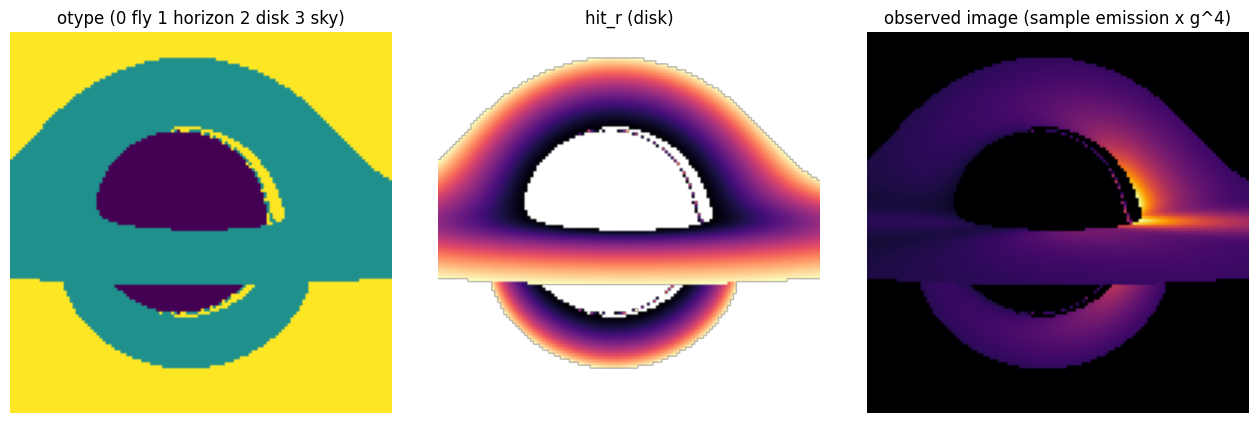

In [5]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import lensing

z = np.load(sorted(glob.glob("/kaggle/working/kerr_lensing/shard_*.npz"))[0])
k = 0
a, incl = z["params"][k]
print(f"sample {k}: a={a:.3f}, incl={incl:.1f} deg, split={z['split'][k]}")

# a simple orbiting-gas emission: brighter inner disk, with streaks in phi
def emission(r, ph):
    return (6.0 / r) ** 2 * (1.0 + 0.5 * np.cos(4 * ph))

img = lensing.emission_to_image(z["otype"][k], z["hit_r"][k].astype("f4"),
                                z["hit_ph"][k].astype("f4"), emission,
                                hit_g=z["hit_g"][k])     # g^4 Doppler + gravitational shift

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
ax[0].imshow(z["otype"][k], cmap="viridis"); ax[0].set_title("otype (0 fly 1 horizon 2 disk 3 sky)")
ax[1].imshow(np.where(z["otype"][k] == 2, z["hit_r"][k], np.nan), cmap="magma"); ax[1].set_title("hit_r (disk)")
ax[2].imshow(img ** 0.4, cmap="inferno"); ax[2].set_title("observed image (sample emission x g^4)")
for a_ in ax: a_.axis("off")
plt.tight_layout(); plt.show()


## Publish it as a Kaggle Dataset

1. **Save Version** (top right) and let it run to completion.
2. Open the finished version, go to the **Output** tab, and choose **New Dataset**
   from `/kaggle/working/kerr_lensing` (or add the output to an existing dataset).
3. In your FNO / inverse / PINN notebooks, **Add Data -> your dataset**; it mounts
   read-only under `/kaggle/input/<name>/`. Load the shards with `numpy.load` and
   read `manifest.json` for the schema and the train/val/test splits.

The stored fields are the forward operator. For the FNO, generate
`(emission -> image)` pairs on the fly with `lensing.emission_to_image` using
random emissions (pass `hit_g` to include the g^4 Doppler + gravitational shift); for the inverse problem, regress `params` from those images or
straight from the fields.
